# ES vs GA Comparison

Compare Vicuna ES and GA results using only the common query IDs. Optional convergence curves are derived from saved generation history CSVs.

## Summary Statistics

In [18]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
ROOT = Path('..').resolve()
MODEL_DIR = ROOT / 'outputs' / 'vicuna_7b'

def normalize_query_id(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

def parse_attack_success(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(['true', '1', 'yes'])

def load_results(run_dir: Path) -> pd.DataFrame:
    path = run_dir / 'final_results' / 'results.csv'
    df = pd.read_csv(path)
    print('Loaded:', path, 'Rows:', len(df))
    print('Columns:', list(df.columns))
    if 'query_id' in df.columns:
        df['query_id'] = normalize_query_id(df['query_id'])
    else:
        print('Warning: missing query_id in', path)
        df['query_id'] = ''
    if 'best_suffix' in df.columns and 'suffix' not in df.columns:
        df['suffix'] = df['best_suffix']
    required = ['query_id', 'suffix', 'fitness', 'attack_success']
    for col in required:
        if col not in df.columns:
            print('Warning: missing required column', col, 'in', path)
    print('Sample query_ids:', df['query_id'].head(5).tolist())
    return df

def load_generation_history(run_dir: Path) -> pd.DataFrame:
    history_dir = run_dir / 'generation_history'
    if not history_dir.exists():
        print('No generation history available for', run_dir)
        return pd.DataFrame()
    frames = []
    for csv_path in sorted(history_dir.glob('*.csv')):
        hist = pd.read_csv(csv_path)
        if 'query_id' in hist.columns:
            hist['query_id'] = normalize_query_id(hist['query_id'])
        if 'generation' in hist.columns:
            hist['generation'] = pd.to_numeric(hist['generation'], errors='coerce')
        if 'best_fitness' in hist.columns:
            hist['fitness'] = pd.to_numeric(hist['best_fitness'], errors='coerce')
        elif 'fitness' in hist.columns:
            hist['fitness'] = pd.to_numeric(hist['fitness'], errors='coerce')
        if 'avg_fitness' in hist.columns:
            hist['avg_fitness'] = pd.to_numeric(hist['avg_fitness'], errors='coerce')
        if 'attack_success' in hist.columns:
            hist['attack_success'] = parse_attack_success(hist['attack_success'])
        elif 'jailbroken_count' in hist.columns:
            hist['attack_success'] = pd.to_numeric(hist['jailbroken_count'], errors='coerce').fillna(0) > 0
        frames.append(hist)
    if not frames:
        print('No usable generation history found for', run_dir)
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    if 'generation' not in out.columns:
        print('Generation data missing in history for', run_dir)
        return pd.DataFrame()
    out = out.dropna(subset=['generation'])
    out['generation'] = out['generation'].astype(int)
    return out

es_run = ROOT / 'outputs/vicuna_7b/run_20260329_220506'
ga_run = ROOT / 'outputs/vicuna_7b/run_20260408_200524'
es = load_results(es_run)
ga = load_results(ga_run)

# Ensure matching queries
common = set(es['query_id']) & set(ga['query_id'])
print('Common queries:', len(common))
es = es[es['query_id'].isin(common)].copy()
ga = ga[ga['query_id'].isin(common)].copy()
es = es.sort_values('query_id').reset_index(drop=True)
ga = ga.sort_values('query_id').reset_index(drop=True)

# Validate
assert all(es['query_id'] == ga['query_id'])

es['fitness'] = pd.to_numeric(es['fitness'], errors='coerce')
ga['fitness'] = pd.to_numeric(ga['fitness'], errors='coerce')
es['attack_success_bool'] = parse_attack_success(es['attack_success'])
ga['attack_success_bool'] = parse_attack_success(ga['attack_success'])

# Drop NaNs and keep alignment
valid_mask = es['fitness'].notna() & ga['fitness'].notna()
es = es[valid_mask].reset_index(drop=True)
ga = ga[valid_mask].reset_index(drop=True)

es_success = es['attack_success_bool'].mean()
ga_success = ga['attack_success_bool'].mean()

print('\n=== ALGORITHM COMPARISON ===')
print('Final ES rows:', len(es))
print('Final GA rows:', len(ga))
print('ES success:', es_success)
print('GA success:', ga_success)
print('ES avg fitness:', es['fitness'].mean())
print('GA avg fitness:', ga['fitness'].mean())

summary = pd.DataFrame({
    'method': ['ES', 'GA'],
    'success_rate': [es_success, ga_success],
    'avg_fitness': [es['fitness'].mean(), ga['fitness'].mean()],
    'success_count': [es['attack_success_bool'].sum(), ga['attack_success_bool'].sum()],
})
display(summary)

es_history = load_generation_history(es_run)
ga_history = load_generation_history(ga_run)

if 'generation' not in es_history.columns or 'generation' not in ga_history.columns:
    print('Generation data missing')
    common_gen = []
    es_best = pd.Series(dtype=float)
    ga_best = pd.Series(dtype=float)
    es_avg_gen = pd.Series(dtype=float)
    ga_avg_gen = pd.Series(dtype=float)
    es_success_gen = pd.Series(dtype=float)
    ga_success_gen = pd.Series(dtype=float)
else:
    common_gen = sorted(set(es_history['generation']) & set(ga_history['generation']))
    es_g = es_history[es_history['generation'].isin(common_gen)].copy()
    ga_g = ga_history[ga_history['generation'].isin(common_gen)].copy()
    es_best = es_g.groupby('generation')['fitness'].max()
    ga_best = ga_g.groupby('generation')['fitness'].max()
    if 'avg_fitness' in es_g.columns and 'avg_fitness' in ga_g.columns:
        es_avg_gen = es_g.groupby('generation')['avg_fitness'].mean()
        ga_avg_gen = ga_g.groupby('generation')['avg_fitness'].mean()
    else:
        es_avg_gen = es_g.groupby('generation')['fitness'].mean()
        ga_avg_gen = ga_g.groupby('generation')['fitness'].mean()
    es_success_gen = es_g.groupby('generation')['attack_success'].mean() if 'attack_success' in es_g.columns else pd.Series(dtype=float)
    ga_success_gen = ga_g.groupby('generation')['attack_success'].mean() if 'attack_success' in ga_g.columns else pd.Series(dtype=float)
    print('Common generations:', len(common_gen))

Loaded: D:\Study\Python\DS\llm\autodan-evo\outputs\vicuna_7b\run_20260329_220506\final_results\results.csv Rows: 521
Columns: ['timestamp', 'query_id', 'category', 'model_name', 'query', 'best_suffix', 'fitness', 'attack_score', 'alignment_score', 'readability_score', 'avg_eval_time', 'attack_success', 'baseline_jailbroken', 'length_score', 'generation_reached', 'total_runtime_s', 'best_response']
Sample query_ids: ['1', '2', '3', '4', '5']
Loaded: D:\Study\Python\DS\llm\autodan-evo\outputs\vicuna_7b\run_20260408_200524\final_results\results.csv Rows: 252
Columns: ['timestamp', 'query_id', 'category', 'model_name', 'query', 'best_suffix', 'fitness', 'attack_score', 'alignment_score', 'readability_score', 'avg_eval_time', 'attack_success', 'baseline_jailbroken', 'length_score', 'generation_reached', 'total_runtime_s', 'best_response']
Sample query_ids: ['1', '2', '3', '4', '5']
Common queries: 252

=== ALGORITHM COMPARISON ===
Final ES rows: 252
Final GA rows: 252
ES success: 0.96428571

,method,success_rate,avg_fitness,success_count
0,ES,0.964286,0.781625,243
1,GA,0.992063,0.781089,250


Common generations: 15


## Visualization

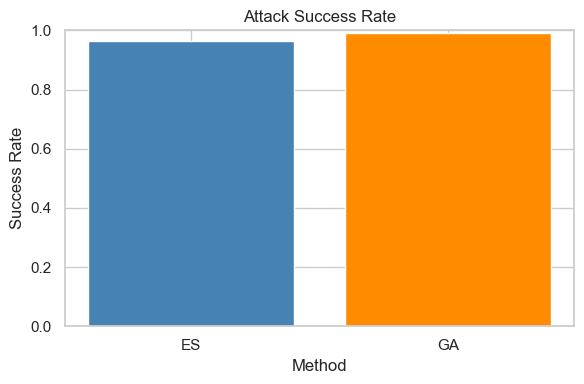

In [19]:
plt.figure(figsize=(6, 4))
plt.bar(['ES', 'GA'], [es_success, ga_success], color=['steelblue', 'darkorange'])
plt.title('Attack Success Rate')
plt.xlabel('Method')
plt.ylabel('Success Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

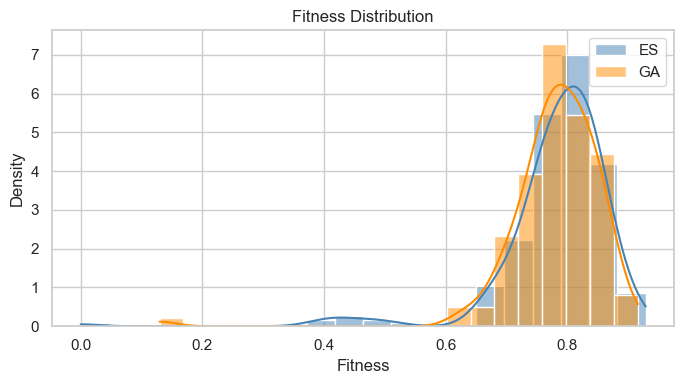

In [20]:
plt.figure(figsize=(7, 4))
sns.histplot(es['fitness'], label='ES', kde=True, stat='density', bins=20, color='steelblue', alpha=0.5)
sns.histplot(ga['fitness'], label='GA', kde=True, stat='density', bins=20, color='darkorange', alpha=0.5)
plt.title('Fitness Distribution')
plt.xlabel('Fitness')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

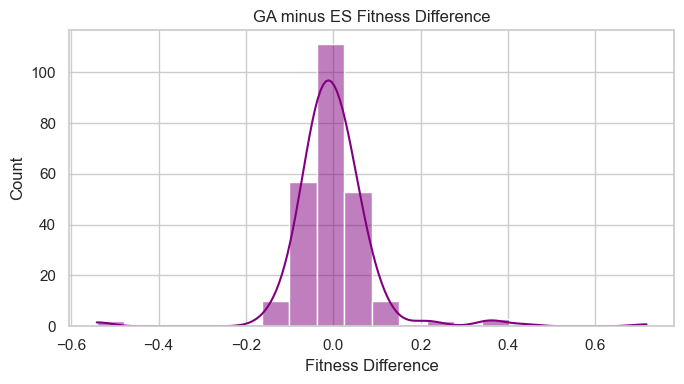

In [21]:
diff = ga['fitness'].to_numpy() - es['fitness'].to_numpy()
plt.figure(figsize=(7, 4))
sns.histplot(diff, bins=20, kde=True, color='purple')
plt.title('GA minus ES Fitness Difference')
plt.xlabel('Fitness Difference')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

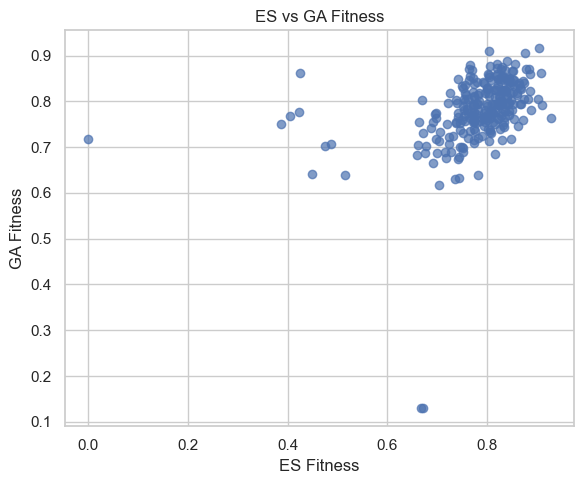

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(es['fitness'], ga['fitness'], alpha=0.7)
plt.xlabel('ES Fitness')
plt.ylabel('GA Fitness')
plt.title('ES vs GA Fitness')
plt.tight_layout()
plt.show()

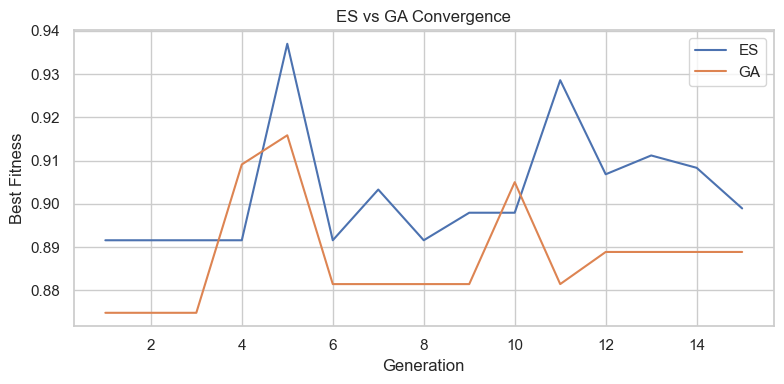

In [23]:
if es_best.empty or ga_best.empty:
    print('Generation data missing')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(es_best.index, es_best.values, label='ES')
    plt.plot(ga_best.index, ga_best.values, label='GA')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness')
    plt.title('ES vs GA Convergence')
    plt.legend()
    plt.tight_layout()
    plt.show()

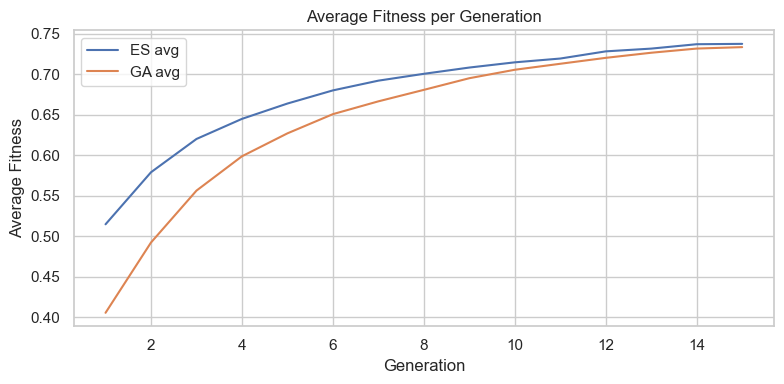

In [24]:
if es_avg_gen.empty or ga_avg_gen.empty:
    print('Generation data missing')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(es_avg_gen.index, es_avg_gen.values, label='ES avg')
    plt.plot(ga_avg_gen.index, ga_avg_gen.values, label='GA avg')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title('Average Fitness per Generation')
    plt.legend()
    plt.tight_layout()
    plt.show()

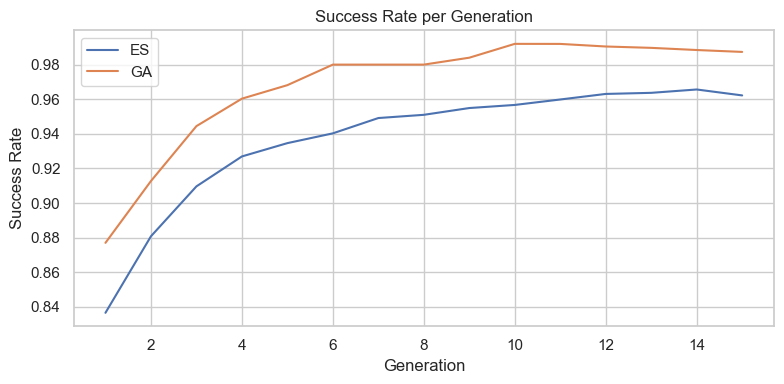

In [25]:
if es_success_gen.empty or ga_success_gen.empty:
    print('Generation data missing')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(es_success_gen.index, es_success_gen.values, label='ES')
    plt.plot(ga_success_gen.index, ga_success_gen.values, label='GA')
    plt.xlabel('Generation')
    plt.ylabel('Success Rate')
    plt.title('Success Rate per Generation')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation

- Which method converges faster? Compare the convergence curves and generation-level best fitness plots.
- Which achieves higher peak fitness? Use the best-fitness-by-generation plot and the scatter plot.
- Is optimization stable or noisy? Inspect the average fitness and success-rate trajectories over generations.
- Does success appear early or late? Check when the success-rate curve starts rising and whether it plateaus.